# Occlusion sensitivity of the sub_model

Sources:  
https://github.com/BUPTLdy/occlusion_experiments/blob/master/Occlusion_experiments.ipynb  
https://github.com/oswaldoludwig/Sensitivity-to-occlusion-Keras-/blob/master/occlusion_sensitivity.py  
https://github.com/matheushent/covid-19-detector/blob/master/vis.py  
https://pypi.org/project/tf-explain/0.0.1a0/  
https://www.mdpi.com/1424-8220/20/11/3307

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score

import keras

import tensorflow as tf


In [9]:
def set_reproducible():
    np.random.seed(12345)
    random.seed(12345)
    tf.random.set_seed(12345)
    keras.utils.set_random_seed(12345)
    
set_reproducible()

In [10]:
dps1200 = pd.read_csv("../../data/dps1200.csv")
dps1200 = dps1200[dps1200["year"] >= 1800]
dps1200.rename(columns=lambda x: x.lower(), inplace=True)
dpa = pd.read_csv("../../data/dpa.csv")
dpa = dpa[dpa["year"] >= 1800]
dpa.rename(columns=lambda x: x.lower(), inplace=True)
daa = pd.read_csv("../../data/daa.csv")
daa = daa[daa["year"] >= 1800]
daa.rename(columns=lambda x: x.lower(), inplace=True)

frames = [dpa, daa, dps1200]

data = pd.concat(frames)

In [ ]:
data.rename(columns=lambda x: x.replace('x', '').strip(), inplace=True)
data = data.drop('tree', axis=1)
data = data.drop('type', axis=1)

data.head()

,year,origin,jahr,3996,2970,2968,2966,2964,2962,2960,...,818,816,814,812,810,808,806,804,802,800
7,1807,BHN,1807.0,0.012190,0.018461,0.018693,0.018933,0.019180,0.019437,0.019703,...,-0.021817,-0.021688,-0.021581,-0.021500,-0.021449,-0.021431,-0.021448,-0.021497,-0.021576,-0.021680
27,1808,BHN,1808.0,0.007680,0.017779,0.018064,0.018360,0.018664,0.018977,0.019297,...,-0.019688,-0.019511,-0.019355,-0.019229,-0.019140,-0.019089,-0.019078,-0.019108,-0.019175,-0.019275
28,1818,BHN,1818.0,0.001696,0.017197,0.017447,0.017709,0.017982,0.018266,0.018564,...,-0.017498,-0.017263,-0.017062,-0.016904,-0.016795,-0.016738,-0.016734,-0.016778,-0.016866,-0.016991
29,1808,BHN,1808.0,0.003949,0.016106,0.016425,0.016753,0.017091,0.017441,0.017805,...,-0.017793,-0.017598,-0.017436,-0.017314,-0.017236,-0.017206,-0.017221,-0.017278,-0.017371,-0.017495
30,1817,BHN,1817.0,0.004788,0.017703,0.018036,0.018375,0.018719,0.019069,0.019424,...,-0.018147,-0.017942,-0.017769,-0.017637,-0.017551,-0.017514,-0.017524,-0.017581,-0.017677,-0.017807


In [12]:
y = data.iloc[:,4:]
xp = y.columns.values
xp = xp.astype(int)

In [13]:
features = data.iloc[:, 4:].values
labels = data.iloc[:, 0].values

In [14]:
train_data, test_data, train_labels, test_labels = train_test_split(features, labels, test_size=0.2, random_state=42)

In [15]:
print(test_data.shape)

(234, 410)


In [16]:
model_path = "1800_sub_model.keras"

In [17]:
dps1200sub_model = tf.keras.models.load_model(model_path)

# Show the model architecture
dps1200sub_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 1,630,021 (6.22 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 1,084,804 (4.14 MB)

In [18]:
print(type(dps1200sub_model))

<class 'keras.src.models.functional.Functional'>


# Occlusion

In [19]:
import math
import seaborn as sns
import copy

## Feature importance for each sample

234 82
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━

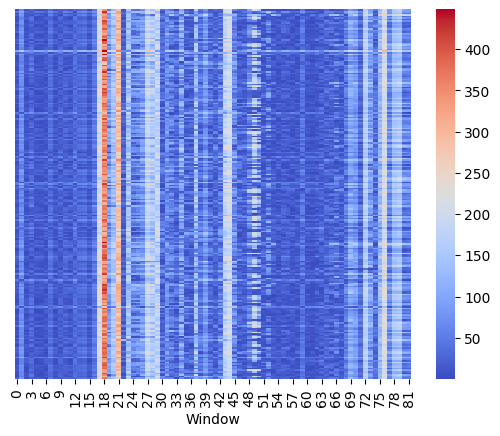

In [20]:
occluding_size = 5
num_columns = test_data.shape[1]
step = occluding_size

output_height = test_data.shape[0]
output_width = math.ceil(num_columns/occluding_size)
print(output_height,output_width)

heatmap = np.zeros((output_height, output_width))
i = 0

for window in range(0, num_columns, step):
   input_data = copy.copy(test_data)
   end_index = min(window + step, num_columns)
   input_data[:, window:end_index] = 0
   output = dps1200sub_model.predict(input_data)
   importance = abs(output.flatten() - test_labels)
   heatmap[:, i] += importance
   i += 1

ax = sns.heatmap(heatmap, cmap='coolwarm', yticklabels=False)
plt.xlabel('Window')
plt.show()
    

## Feature importance for sorted samples

In [21]:
test_labels_2d = test_labels.reshape(-1, 1)
test_all = np.concatenate((test_labels_2d, test_data), axis=1)


sorted_indices = np.argsort(test_all[:, 0])
test_all_sorted = test_all[sorted_indices]

sorted_test_labels = test_all_sorted[:, 0]
sorted_test_data = test_all_sorted[:, 1:]

print("Sortierte Labels:")
print(sorted_test_labels)
print("\nSortierte Daten:")
print(sorted_test_data)

Sortierte Labels:
[1800. 1800. 1800. 1801. 1801. 1803. 1803. 1806. 1806. 1808. 1808. 1809.
 1809. 1810. 1811. 1811. 1813. 1813. 1815. 1815. 1816. 1820. 1820. 1820.
 1822. 1823. 1825. 1825. 1826. 1827. 1827. 1830. 1831. 1832. 1834. 1835.
 1835. 1836. 1836. 1837. 1838. 1839. 1840. 1841. 1841. 1842. 1844. 1845.
 1846. 1848. 1848. 1848. 1848. 1849. 1850. 1851. 1851. 1852. 1852. 1852.
 1854. 1855. 1857. 1858. 1860. 1860. 1860. 1861. 1862. 1862. 1864. 1865.
 1867. 1868. 1868. 1870. 1871. 1872. 1874. 1874. 1875. 1875. 1875. 1876.
 1877. 1878. 1878. 1881. 1881. 1882. 1882. 1883. 1885. 1885. 1887. 1890.
 1890. 1890. 1891. 1895. 1897. 1900. 1900. 1900. 1901. 1902. 1902. 1903.
 1903. 1903. 1904. 1905. 1906. 1907. 1907. 1907. 1908. 1910. 1911. 1912.
 1912. 1912. 1912. 1915. 1916. 1917. 1918. 1919. 1920. 1920. 1920. 1922.
 1922. 1923. 1923. 1924. 1925. 1925. 1926. 1928. 1929. 1930. 1931. 1932.
 1934. 1934. 1935. 1937. 1937. 1938. 1939. 1939. 1940. 1941. 1942. 1942.
 1943. 1944. 1946. 1947. 1947. 19

234 82
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━

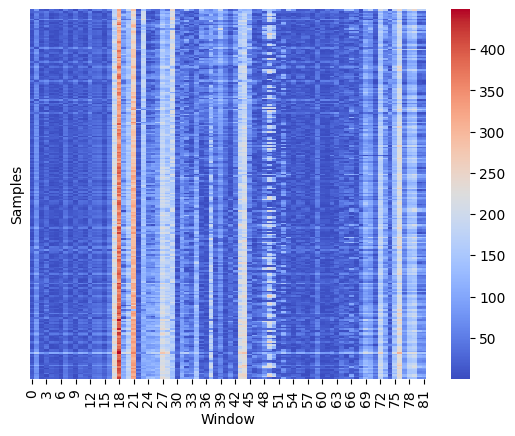

In [22]:
occluding_size = 5
num_columns = sorted_test_data.shape[1]
step = occluding_size

output_height = sorted_test_data.shape[0]
output_width = math.ceil(num_columns/occluding_size)
print(output_height,output_width)

heatmap = np.zeros((output_height, output_width))
i = 0

for window in range(0, num_columns, step):
   input_data = copy.copy(sorted_test_data)
   end_index = min(window + step, num_columns)
   input_data[:, window:end_index] = 0
   output = dps1200sub_model.predict(input_data)
   importance = abs(output.flatten() - sorted_test_labels)
   heatmap[:, i] += importance
   i += 1

ax = sns.heatmap(heatmap, cmap='coolwarm', yticklabels=False)
plt.xlabel('Window')
plt.ylabel('Samples')
plt.show()

## Feature importance for each century

In [23]:
from typing import List

In [24]:
def convertToCentury(y: List[int]) -> List[int]: 
    return [int(str(year)[:2]) for year in y]
centuries = convertToCentury(sorted_test_labels)

In [25]:
unique_centuries, counts = np.unique(centuries, return_counts=True)
print(unique_centuries, counts)
print(len(counts))

[18 19 20] [101 128   5]
3


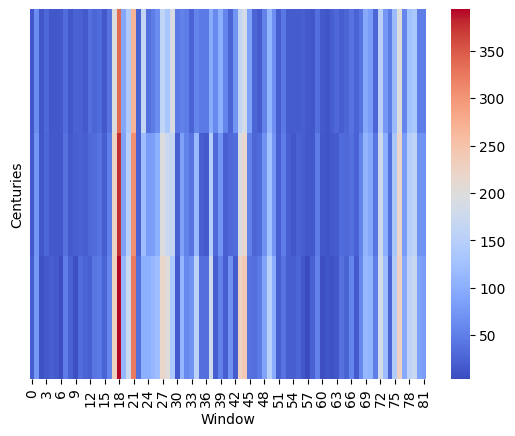

In [26]:
mean_values = []
i = 0
output_height2 = len(counts)
output_width = math.ceil(num_columns/occluding_size)

heatmap2 = np.zeros((output_height2, output_width))

start_row = 0
for count in counts:
    group_data = heatmap[start_row:start_row+count]
    group_mean = np.mean(group_data, axis=0)    
    heatmap2[i,:] += group_mean
    i += 1
    start_row += count

ax = sns.heatmap(heatmap2, cmap='coolwarm', yticklabels=False)
plt.xlabel('Window')
plt.ylabel('Centuries')
plt.show()

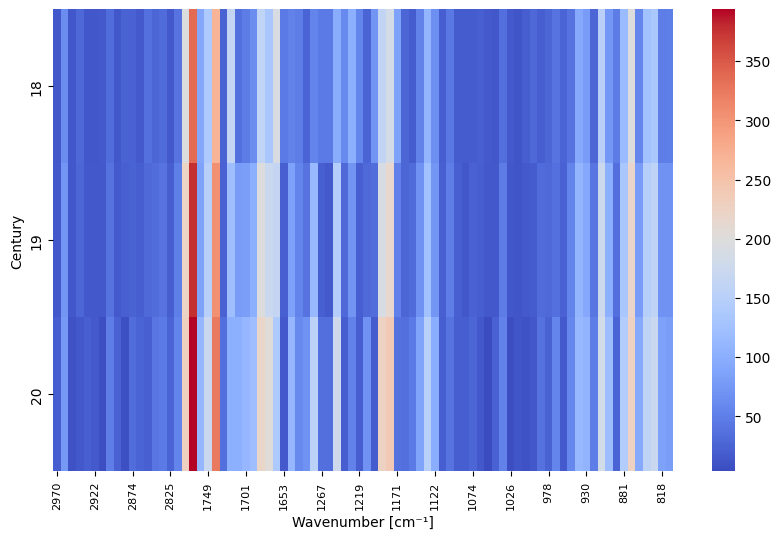

In [27]:
mean_values = []
i = 0
output_height2 = len(counts)
output_width = math.ceil(num_columns/occluding_size)

heatmap2 = np.zeros((output_height2, output_width))

start_row = 0
for count in counts:
    group_data = heatmap[start_row:start_row+count]
    group_mean = np.mean(group_data, axis=0)    
    heatmap2[i,:] += group_mean
    i += 1
    start_row += count

plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap2, cmap='coolwarm')
wavelengths = xp[::25]
plt.xticks(ticks=np.arange(0.5, heatmap2.shape[1] + 0.5, 5), labels=wavelengths, fontsize=8)
plt.xlabel('Wavenumber [cm⁻¹]')

centuries = unique_centuries
plt.yticks(ticks=np.arange(0.5, heatmap2.shape[0] + 0.5), labels=centuries)
plt.ylabel('Century')
plt.show()

In [28]:
print(heatmap.shape)

(234, 82)


In [29]:
print(xp.shape)

(410,)


# Heatmap for Comparison

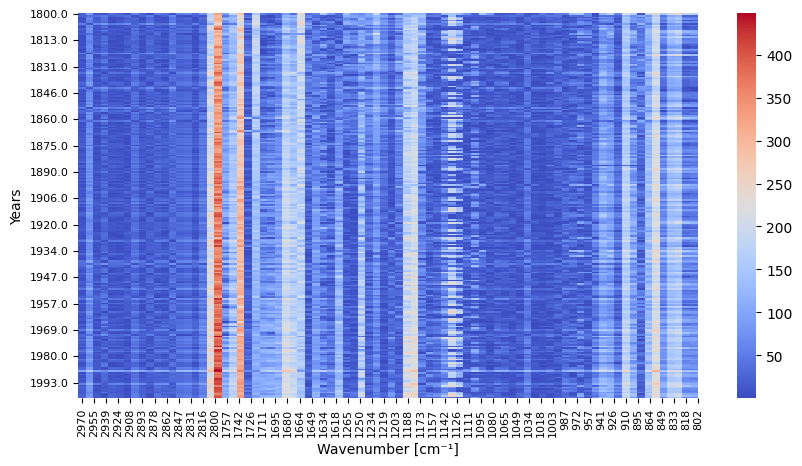

In [30]:
# Plot Heatmap
wavelengths = xp[::8]
years = sorted_test_labels[::16]

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap, cmap='coolwarm')
plt.xlabel('Wavenumber [cm⁻¹]')
plt.ylabel('Years')
plt.xticks(ticks=np.arange(0.5, heatmap.shape[1] + 0.5, 1.6), labels=wavelengths, fontsize=8)
plt.yticks(ticks=np.arange(0.5, heatmap.shape[0] + 0.5, 16), labels=years, fontsize=8)
plt.show()